In [63]:
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

In [12]:
# Zadanie 1: Klasyfikacja binarna – Breast Cancer 
data_bc = load_breast_cancer()
X_bc = data_bc.data
y_bc = data_bc.target

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42)

In [3]:
X_train_bc[:5]

array([[9.029e+00, 1.733e+01, 5.879e+01, 2.505e+02, 1.066e-01, 1.413e-01,
        3.130e-01, 4.375e-02, 2.111e-01, 8.046e-02, 3.274e-01, 1.194e+00,
        1.885e+00, 1.767e+01, 9.549e-03, 8.606e-02, 3.038e-01, 3.322e-02,
        4.197e-02, 9.559e-03, 1.031e+01, 2.265e+01, 6.550e+01, 3.247e+02,
        1.482e-01, 4.365e-01, 1.252e+00, 1.750e-01, 4.228e-01, 1.175e-01],
       [2.109e+01, 2.657e+01, 1.427e+02, 1.311e+03, 1.141e-01, 2.832e-01,
        2.487e-01, 1.496e-01, 2.395e-01, 7.398e-02, 6.298e-01, 7.629e-01,
        4.414e+00, 8.146e+01, 4.253e-03, 4.759e-02, 3.872e-02, 1.567e-02,
        1.798e-02, 5.295e-03, 2.668e+01, 3.348e+01, 1.765e+02, 2.089e+03,
        1.491e-01, 7.584e-01, 6.780e-01, 2.903e-01, 4.098e-01, 1.284e-01],
       [9.173e+00, 1.386e+01, 5.920e+01, 2.609e+02, 7.721e-02, 8.751e-02,
        5.988e-02, 2.180e-02, 2.341e-01, 6.963e-02, 4.098e-01, 2.265e+00,
        2.608e+00, 2.352e+01, 8.738e-03, 3.938e-02, 4.312e-02, 1.560e-02,
        4.192e-02, 5.822e-03, 1.001e

In [7]:
scaler = MinMaxScaler()
X_train_bc = scaler.fit_transform(X_train_bc)
X_test_bc = scaler.transform(X_test_bc)

In [10]:
X_train_bc.shape

(455, 30)

In [8]:
print(X_train_bc[:5])

[[0.06552721 0.25769361 0.07732252 0.03436883 0.48722578 0.41750565
  0.73336457 0.21744533 0.50400427 0.64237574 0.07818215 0.18427334
  0.05314988 0.02029892 0.26637658 0.62943491 0.76717172 0.62928585
  0.63623129 0.29933115 0.05964476 0.28331557 0.05597072 0.02508436
  0.523195   0.44938009 1.         0.60137457 0.52493594 0.52950153]
 [0.65620256 0.57017247 0.67420686 0.48940187 0.55493365 0.90343127
  0.58270853 0.74353877 0.65563267 0.50589722 0.18768785 0.08899841
  0.17231306 0.13944393 0.08634463 0.34050831 0.09777778 0.29683652
  0.18847288 0.1520183  0.65791974 0.57196162 0.62025316 0.46283247
  0.52930789 0.80287939 0.54153355 0.9975945  0.49931007 0.62190573]
 [0.07257946 0.14034494 0.08023901 0.0388312  0.22190124 0.23330594
  0.14029991 0.1083499  0.62680192 0.4142797  0.108021   0.42096888
  0.0872167  0.03122537 0.23880749 0.2788476  0.10888889 0.29551051
  0.63529807 0.17022512 0.04868065 0.19216418 0.05642824 0.02146189
  0.18467704 0.15430316 0.11158147 0.174811   

In [14]:
model_bc = Sequential([
    Input(shape=(X_train_bc.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_bc.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [15]:
history_bc = model_bc.fit(X_train_bc, y_train_bc, epochs=20, batch_size=16, validation_split=0.2)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3830 - loss: 58.7938 - val_accuracy: 0.8791 - val_loss: 0.8596
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8743 - loss: 1.7629 - val_accuracy: 0.9011 - val_loss: 0.9408
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8505 - loss: 1.0104 - val_accuracy: 0.9011 - val_loss: 0.9615
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8984 - loss: 0.7497 - val_accuracy: 0.9011 - val_loss: 0.9133
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8985 - loss: 0.7836 - val_accuracy: 0.8571 - val_loss: 0.8687
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8850 - loss: 0.6920 - val_accuracy: 0.9121 - val_loss: 1.0468
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9296 - loss: 0.5664 - val_accuracy: 0.9011 - val_loss: 0.9340
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9195 - loss: 0.4517 - val_accuracy: 0.9011 - val_loss

In [1]:
y_pred_prob = model_bc.predict(X_test_bc).flatten()
print(y_pred_prob)
y_pred = (y_pred_prob > 0.5).astype(int)
print(y_pred)

NameError: name 'model_bc' is not defined

In [20]:
acc = accuracy_score(y_test_bc, y_pred)
prec = precision_score(y_test_bc, y_pred)
rec = recall_score(y_test_bc, y_pred)
spec = recall_score(y_test_bc, y_pred, pos_label=0)
cm = confusion_matrix(y_test_bc, y_pred)

In [23]:
print("acc:",acc)
print("prec:",prec)
print("rec:",rec)
print("spec:",spec)

acc: 0.9473684210526315
prec: 0.9577464788732394
rec: 0.9577464788732394
spec: 0.9302325581395349


Text(95.72222222222221, 0.5, 'Rzeczywiste')

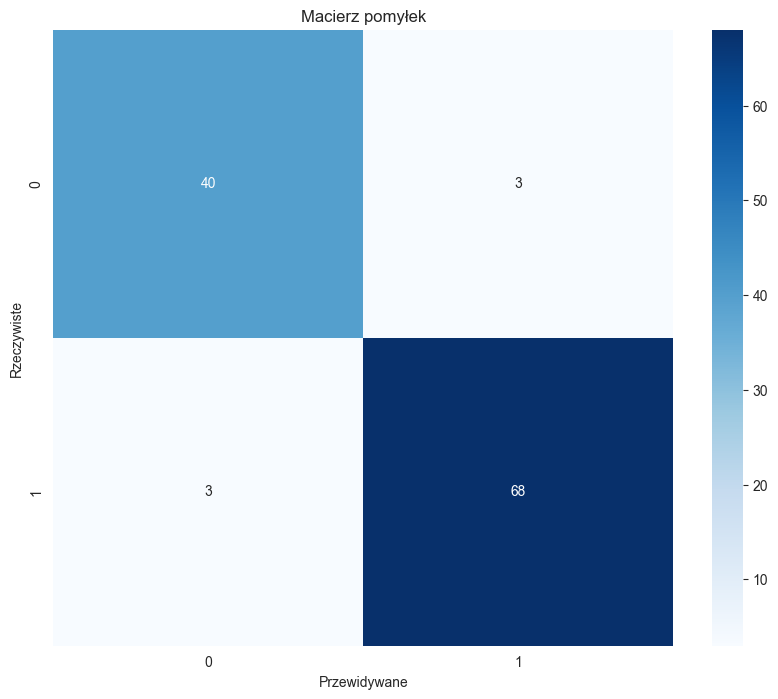

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap='Blues')
plt.title("Macierz pomyłek")
plt.xlabel("Przewidywane")
plt.ylabel("Rzeczywiste")

In [ ]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [34]:
# --- Zadanie 2: Klasyfikacja wieloklasowa – Iris
data_iris = load_iris()
X_iris = data_iris.data
y_iris = data_iris.target
print(X_iris.shape)
print(y_iris.shape)
print(X_iris[:5])
print(y_iris[:150])

(150, 4)
(150,)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [38]:
y_iris_categorical = to_categorical(y_iris)
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris, y_iris_categorical, test_size=0.2, random_state=42)
print(X_train_iris[:5])
print(y_train_iris[:5])
print(len(X_train_iris))

[[4.6 3.6 1.  0.2]
 [5.7 4.4 1.5 0.4]
 [6.7 3.1 4.4 1.4]
 [4.8 3.4 1.6 0.2]
 [4.4 3.2 1.3 0.2]]
[[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]
120


In [42]:
scaler1 = MinMaxScaler()
X_train_iris = scaler1.fit_transform(X_train_iris)
X_test_iris = scaler1.transform(X_test_iris)
print(X_train_iris[:5])
print(X_test_iris[:5])

[[0.08823529 0.66666667 0.         0.04166667]
 [0.41176471 1.         0.0877193  0.125     ]
 [0.70588235 0.45833333 0.59649123 0.54166667]
 [0.14705882 0.58333333 0.10526316 0.04166667]
 [0.02941176 0.5        0.05263158 0.04166667]]
[[0.52941176 0.33333333 0.64912281 0.45833333]
 [0.41176471 0.75       0.12280702 0.08333333]
 [1.         0.25       1.03508772 0.91666667]
 [0.5        0.375      0.61403509 0.58333333]
 [0.73529412 0.33333333 0.66666667 0.54166667]]


In [46]:
print(X_train_iris.shape)
print(X_test_iris.shape)

(120, 4)
(30, 4)


In [37]:
model_iris = Sequential([
    Input(shape=(X_train_iris.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model_iris.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [39]:
# Trening
history_iris = model_iris.fit(X_train_iris, y_train_iris, epochs=30, batch_size=8, validation_split=0.2)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.2708 - loss: 1.0831 - val_accuracy: 0.7083 - val_loss: 0.9075
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6795 - loss: 0.9491 - val_accuracy: 1.0000 - val_loss: 0.8441
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8416 - loss: 0.8571 - val_accuracy: 1.0000 - val_loss: 0.7851
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8342 - loss: 0.7673 - val_accuracy: 0.6250 - val_loss: 0.7608
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8444 - loss: 0.7123 - val_accuracy: 1.0000 - val_loss: 0.6591
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8067 - loss: 0.6230 - val_accuracy: 1.0000 - val_loss: 0.6209
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9304 - loss: 0.5782 - val_accuracy: 0.7500 - val_loss: 0.6139
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8902 - loss: 0.5571 - val_accuracy: 1.0000 - val_loss

In [40]:
print(history_iris.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [50]:
y_pred_iris = model_iris.predict(X_test_iris)
y_pred_iris_labels = np.argmax(y_pred_iris, axis=1)
y_test_iris_labels = np.argmax(y_test_iris, axis=1)

acc1 = accuracy_score(y_test_iris_labels, y_pred_iris_labels)
prec1 = precision_score(y_test_iris_labels, y_pred_iris_labels, average='macro')
rec1 = recall_score(y_test_iris_labels, y_pred_iris_labels, average='macro')

print("acc:",acc1)
print("prec:",prec1)
print("rec:",rec1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
acc: 0.8666666666666667
prec: 0.872053872053872
rec: 0.872053872053872


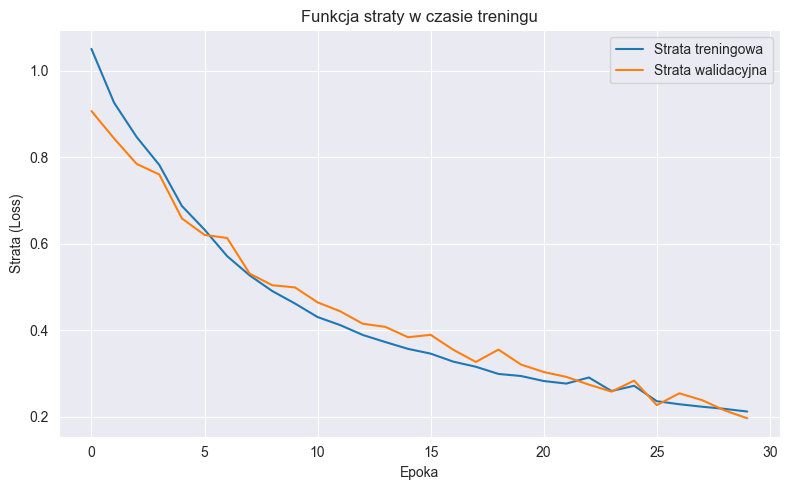

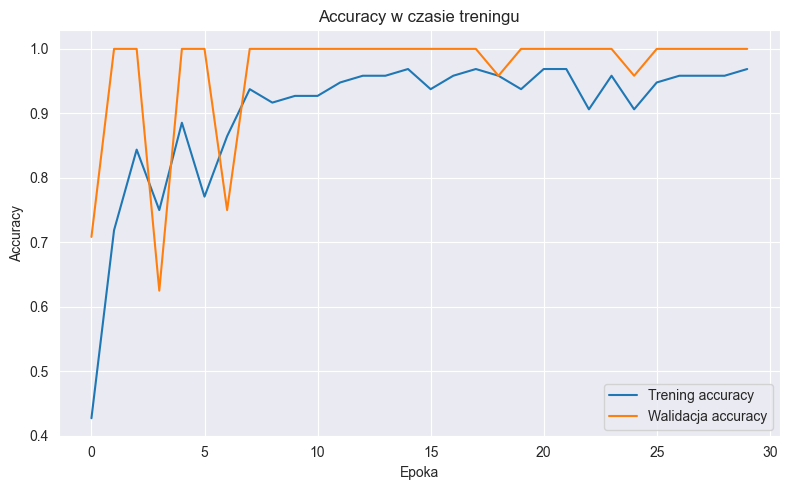

In [53]:
plt.figure(figsize=(8, 5))
plt.plot(history_iris.history['loss'], label='Strata treningowa')
plt.plot(history_iris.history['val_loss'], label='Strata walidacyjna')
plt.title('Funkcja straty w czasie treningu')
plt.xlabel('Epoka')
plt.ylabel('Strata (Loss)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_iris.history['accuracy'], label='Trening accuracy')
plt.plot(history_iris.history['val_accuracy'], label='Walidacja accuracy')
plt.title('Accuracy w czasie treningu')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [65]:
import tensorflow as tf
# import tensorflow_datasets as tfds
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# # 1. Załaduj zbiór VGGFace2 z TensorFlow Datasets
# dataset, info = tfds.load('vgg_face', split=['train', 'test'], with_info=True, as_supervised=True)
# train_ds, test_ds = dataset
# num_classes = info.features['label'].num_classes

In [ ]:
 tf.data.Datasets 

In [ ]:
#!/usr/bin/env python3
"""deep_learning_project_template.py
====================================================

🔍 **Cel pliku**

Ten szablon łączy *większość kluczowych elementów* wspólnych dla zadań: 
1. Klasyfikacja binarna (Breast Cancer)  
2. Klasyfikacja wieloklasowa (Iris)  
3. Transfer learning (VGGFace/VGG16)  
4. Klasyfikacja obrazów COCO (przykład uproszczony)  
5. Segmentacja (CamVid / U‑Net)  

📝 **Wnioski, uwagi i odpowiedzi** umieszczamy w komentarzach `# >>>` **przy blokach kodu**.  
Dzięki temu wystarczy jeden plik źródłowy, który można otworzyć w IDE / JupyterLab i natychmiast uruchomić lub rozszerzać.

Wymagane pakiety ⇢ patrz `requirements.txt` na końcu pliku.
"""

# ------------------------------------------------------------
# 0. Typowe importy, konfiguracja środowiska
# ------------------------------------------------------------
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer, OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers

# >>> Uwaga: utrzymujemy powtarzalność eksperymentu — ustawiamy ziarno losowe.
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# 1. Pomocnicze funkcje i klasy (DRY)
# ------------------------------------------------------------


def plot_history(history, title="Historia uczenia"):
    """Wizualizacja krzywych uczenia (loss & accuracy)."""
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    axs[0].plot(history.history["loss"], label="loss")
    axs[0].plot(history.history.get("val_loss", []), label="val_loss")
    axs[0].set_title(f"{title} – Loss")
    axs[0].legend()

    axs[1].plot(history.history["accuracy"], label="acc")
    axs[1].plot(history.history.get("val_accuracy", []), label="val_acc")
    axs[1].set_title(f"{title} – Accuracy")
    axs[1].legend()
    plt.tight_layout()
    plt.show()



def print_classification_report(y_true, y_pred, target_names=None, average="binary"):
    """Drukuje pełny zestaw metryk + macierz pomyłek."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=average)
    rec = recall_score(y_true, y_pred, average=average)
    # Specyficzność = TN / (TN + FP)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (np.nan, np.nan, np.nan, np.nan)
    specificity = tn / (tn + fp) if tn + fp > 0 else np.nan

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall/Sensitivity:", rec)
    print("Specificity:", specificity)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(cmap="Blues")
    plt.show()


# ------------------------------------------------------------
# 2. Zadanie: Klasyfikacja binarna (Breast Cancer)
# ------------------------------------------------------------
"""Datasets: Breast Cancer Wisconsin Diagnostic Dataset (sklearn)."""
from sklearn.datasets import load_breast_cancer


def load_breast_cancer_data(test_size=0.2):
    data = load_breast_cancer()
    X, y = data.data, data.target
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=SEED, stratify=y
    )
    scaler = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)
    return (X_train, X_test, y_train, y_test, data.feature_names)



def build_binary_model(input_dim):
    model = models.Sequential(
        [
            layers.Input(shape=(input_dim,)),
            layers.Dense(30, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(15, activation="relu"),
            layers.Dense(1, activation="sigmoid"),
        ]
    )
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model



def run_breast_cancer_example(epochs=40):
    X_train, X_test, y_train, y_test, _ = load_breast_cancer_data()
    model = build_binary_model(X_train.shape[1])
    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=32,
        verbose=0,
    )
    plot_history(history, "Breast Cancer")
    y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
    print_classification_report(y_test, y_pred, target_names=["malignant", "benign"])


# ------------------------------------------------------------
# 3. Zadanie: Klasyfikacja wieloklasowa (Iris)
# ------------------------------------------------------------
"""Dataset: Iris (sklearn)"""
from sklearn.datasets import load_iris


def load_iris_data(test_size=0.2):
    data = load_iris()
    X, y = data.data, data.target
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=SEED, stratify=y
    )
    scaler = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    # One‑hot
    enc = OneHotEncoder(sparse_output=False).fit(y_train.reshape(-1, 1))
    y_train_oh = enc.transform(y_train.reshape(-1, 1))
    y_test_oh = enc.transform(y_test.reshape(-1, 1))
    return (X_train, X_test, y_train_oh, y_test_oh, y_test, data.target_names)



def build_iris_model(input_dim, num_classes):
    model = models.Sequential(
        [
            layers.Input(shape=(input_dim,)),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.2),
            layers.Dense(32, activation="relu"),
            layers.Dense(num_classes, activation="softmax"),
        ]
    )
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model



def run_iris_example(epochs=100):
    X_train, X_test, y_train_oh, y_test_oh, y_test_int, target_names = load_iris_data()
    model = build_iris_model(X_train.shape[1], y_train_oh.shape[1])

    cb_early = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    history = model.fit(
        X_train,
        y_train_oh,
        validation_split=0.2,
        epochs=epochs,
        batch_size=16,
        callbacks=[cb_early],
        verbose=0,
    )
    plot_history(history, "Iris")

    y_pred_int = model.predict(X_test).argmax(axis=1)
    print_classification_report(
        y_test_int, y_pred_int, target_names=target_names, average="macro"
    )


# ------------------------------------------------------------
# 4. Zadanie: Transfer learning na VGGFace (lub VGG16)
# ------------------------------------------------------------
"""Uwaga: Baza VGGFace wymaga pobrania obrazów i etykiet spoza repozytorium.
Ten blok pokazuje minimalny pipeline — wymaga przygotowanego folderu /tf_records.
"""


def build_transfer_model(num_classes):
    base_model = applications.VGG16(
        include_top=False, weights="imagenet", input_shape=(224, 224, 3)
    )
    base_model.trainable = False  # >>> zamrożenie wag; typowy błąd: zapomnieć odblokować!

    inputs = layers.Input(shape=(224, 224, 3))
    x = applications.vgg16.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


# ------------------------------------------------------------
# 5. Klasyfikacja obrazów COCO (przykład: transfer learning MobileNetV2)
# ------------------------------------------------------------
"""Pełne uczenie od zera na COCO jest niepraktyczne ↠ pokazujemy schemat fine‑tune.
Potencjalny problem: pamięć GPU (COCO ma >200 k zdjęć). Rozwiążemy to:
• używając generatora tf.data + pre‑przetworzonych JPEG‑ów,
• wczytując wycinek klasy.
"""

# TODO: Implementacja generatorów tf.data dla COCO → patrz TensorFlow Datasets.

# ------------------------------------------------------------
# 6. Segmentacja obrazu CamVid (U‑Net)
# ------------------------------------------------------------
"""CamVid ma etykiety pikselowe w formacie PNG. Architektura U‑Net jest standardem.
Poniżej – szkic kanałów wejścia/wyjścia; pełny kod w oddzielnym module.
"""


def build_unet(input_shape=(256, 256, 3), num_classes=32):
    inputs = layers.Input(shape=input_shape)
    # Encoder
    c1 = layers.Conv2D(64, 3, activation="relu", padding="same")(inputs)
    c1 = layers.Conv2D(64, 3, activation="relu", padding="same")(c1)
    p1 = layers.MaxPooling2D()(c1)
    # … (dodaj kolejne bloki) …
    # Decoder (upsampling + skip connections)
    # …
    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(p1)  # skrócone
    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=optimizers.Adam(1e-4),
        loss="categorical_crossentropy",  # lub DiceLoss / focal
        metrics=["accuracy"],
    )
    return model

# ------------------------------------------------------------
# 7. Główny runner (CLI) – uruchamiamy tylko lekki demo
# ------------------------------------------------------------
if __name__ == "__main__":
    # demo: Breast Cancer + Iris
    run_breast_cancer_example(epochs=30)
    run_iris_example(epochs=80)